In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import seaborn as sns
import torch
import pandas as pd

device = torch.device("cuda:0")

def load_model_and_tokenizer(model_name):
    """Load model and tokenizer for given model name"""
    print(f"\nLoading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    return model, tokenizer

def evaluate_model(df, model, tokenizer):
    """Evaluate predictions for entire dataset using specified model"""
    results = []
    print(f"\nEvaluating...")
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            result = predict_and_evaluate(row, model, tokenizer)
            results.append(result)
        except Exception as e:
            print(f"Error processing row: {row['input']}")
            print(f"Error message: {str(e)}")
            results.append({'generated_text': '', 'is_correct': False})
    
    df_results = df.copy()
    df_results['generated_text'] = [r['generated_text'] for r in results]
    df_results['is_correct'] = [r['is_correct'] for r in results]
    
    accuracy = df_results['is_correct'].mean()
    accuracy_by_position = df_results.groupby('target_position')['is_correct'].mean()
    
    return df_results, accuracy, accuracy_by_position

def predict_and_evaluate(row, model, tokenizer):
    """Make prediction for a single row using specified model"""
    input_text = row['input']
    target_completion = row['completion']
    target_position = row['target_position']
    
    input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)
    input_length = input_ids.shape[1]
    
    outputs = model.generate(input_ids, max_new_tokens=2, do_sample=False)
    generated_text = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
    
    is_correct = target_completion.lower() in generated_text.lower()
    
    return {
        'generated_text': generated_text,
        'is_correct': is_correct
    }

model, tokenizer = load_model_and_tokenizer('tiiuae/falcon-mamba-7b')

# iterate over csv
files = ['/home/bhaskar_mukhoty/Hilal/MambaInterp/dataset/6_same_relation.csv','/home/bhaskar_mukhoty/Hilal/MambaInterp/dataset/12_same_relation.csv','/home/bhaskar_mukhoty/Hilal/MambaInterp/dataset/16_same_relation.csv','/home/bhaskar_mukhoty/Hilal/MambaInterp/dataset/20_same_relation.csv']
length = [6,12,16,20]
accuracy = {}
for i, file in enumerate(files):
    df = pd.read_csv(files)
    
    df_results, accuracy, accuracy_by_position = evaluate_model(df, model, tokenizer)


SyntaxError: invalid syntax (1719327487.py, line 3)

In [1]:
import pandas as pd

dataset = '/home/bhaskar_mukhoty/Hilal/Kia/Mamba_Research/MemoryLensV2/dataset/new_data_same_relation.csv'
df = pd.read_csv(dataset)
df

,input,target_position,completion
0,James loves Paul. Emma loves Chris. Sarah love...,1,Paul
1,James sees Peter. John sees Kate. Mary sees To...,1,Peter
2,Emma hates Peter. John hates Tom. James hates ...,1,Peter
3,James helps Chris. Mark helps Anna. Mary helps...,1,Chris
4,Alex sees Kate. James sees Peter. Mary sees Mi...,1,Kate
...,...,...,...
155,James helps Mike. Alex helps Peter. Mary helps...,8,Susan
156,David hates Kate. Alex hates Chris. Emma hates...,8,Paul
157,Emma sees Paul. Mary sees Tom. Mark sees Kate....,8,Anna
158,David sees Mike. Emma sees Susan. Mark sees Ka...,8,Paul



Loading tiiuae/falcon-mamba-7b...


/home/bhaskar_mukhoty/miniconda3/envs/mamba/lib/python3.12/site-packages/transformers/kernels/falcon_mamba/selective_scan_with_ln_interface.py:220: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/bhaskar_mukhoty/miniconda3/envs/mamba/lib/python3.12/site-packages/transformers/kernels/falcon_mamba/selective_scan_with_ln_interface.py:350: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


Evaluating tiiuae/falcon-mamba-7b...


100%|██████████| 160/160 [00:29<00:00,  5.47it/s]


<Figure size 1200x800 with 0 Axes>

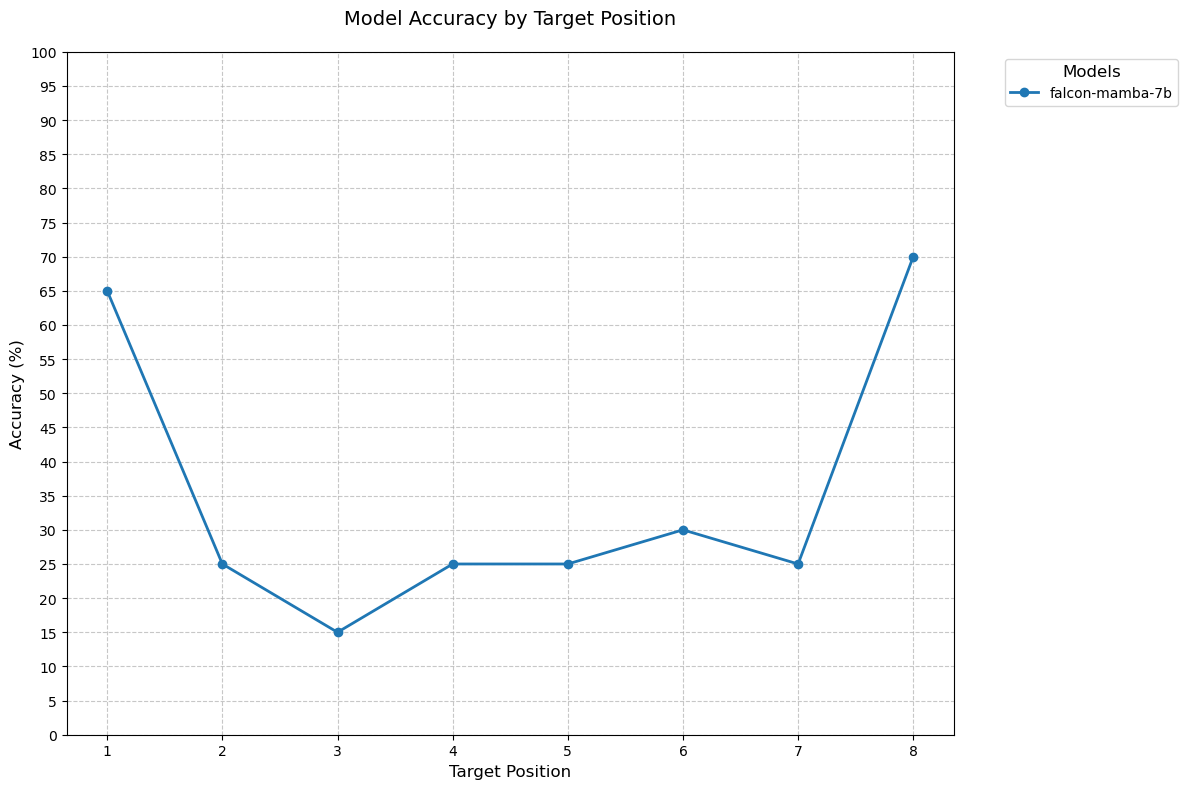

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm import tqdm
import seaborn as sns
import torch
import pandas as pd

# dataset = '/home/bhaskar_mukhoty/Hilal/Kia/Mamba_Research/MemoryLens/position1_data.csv'
# df = pd.read_csv(dataset)
# df

# Set GPU device
#torch.cuda.set_device(0)
device = torch.device("cuda:0")

def load_model_and_tokenizer(model_name):
    """Load model and tokenizer for given model name"""
    print(f"\nLoading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    return model, tokenizer

def predict_and_evaluate(row, model, tokenizer):
    """Make prediction for a single row using specified model"""
    input_text = row['input']
    target_completion = row['completion']
    target_position = row['target_position']
    
    input_ids = tokenizer(input_text, return_tensors="pt").input_ids.to(device)
    input_length = input_ids.shape[1]
    
    outputs = model.generate(input_ids, max_new_tokens=2, do_sample=False)
    generated_text = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True)
    
    is_correct = target_completion.lower() in generated_text.lower()
    
    return {
        'generated_text': generated_text,
        'is_correct': is_correct
    }

def evaluate_model(df, model, tokenizer, model_name):
    """Evaluate predictions for entire dataset using specified model"""
    results = []
    print(f"\nEvaluating {model_name}...")
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        try:
            result = predict_and_evaluate(row, model, tokenizer)
            results.append(result)
        except Exception as e:
            print(f"Error processing row: {row['input']}")
            print(f"Error message: {str(e)}")
            results.append({'generated_text': '', 'is_correct': False})
    
    df_results = df.copy()
    df_results['generated_text'] = [r['generated_text'] for r in results]
    df_results['is_correct'] = [r['is_correct'] for r in results]
    
    accuracy = df_results['is_correct'].mean()
    accuracy_by_position = df_results.groupby('target_position')['is_correct'].mean()
    
    return df_results, accuracy, accuracy_by_position

def plot_accuracy_comparison(accuracies_by_position, model_names):
    """Create plot comparing accuracy by position for different models"""
    plt.figure(figsize=(12, 8))
    
    for model_name, accuracies in accuracies_by_position.items():
        plt.plot(accuracies.index, accuracies.values * 100, marker='o', label=model_name.split('/')[-1], linewidth=2)
    
    plt.title('Model Accuracy by Target Position', fontsize=14, pad=20)
    plt.xlabel('Target Position', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.yticks(range(0, 101, 5))  # Set y-axis ticks from 0 to 100 with step of 5
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Models', title_fontsize=12, fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    return plt.gcf()


# List of models to compare
model_names = [
    'tiiuae/falcon-mamba-7b',
]

# Store results for each model
all_accuracies = {}
all_accuracies_by_position = {}
model_predictions = {}  # New dictionary to store individual model results

# Evaluate each model
for model_name in model_names:
    # Load model and tokenizer
    model, tokenizer = load_model_and_tokenizer(model_name)
    
    # Evaluate model
    df_results, accuracy, accuracy_by_position = evaluate_model(df, model, tokenizer, model_name)
    
    # Store results
    all_accuracies[model_name] = accuracy
    all_accuracies_by_position[model_name] = accuracy_by_position
    model_predictions[model_name] = df_results  # Store the full results DataFrame
    
    # Save individual model results
    model_short_name = model_name.split('/')[-1]
    #df_results.to_csv(f'results_new_data_different_predictions_{model_short_name}.csv', index=False)
    
    # Clear GPU memory
    del model
    del tokenizer
    torch.cuda.empty_cache()
    #torch.cuda.set_device(0)

plt.figure(figsize=(12, 8))
fig = plot_accuracy_comparison(all_accuracies_by_position, model_names)
#plt.savefig('new_data_same_relations_comparison_3.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [4]:
all_accuracies_by_position

{'tiiuae/falcon-mamba-7b': target_position
 1    0.65
 2    0.25
 3    0.15
 4    0.25
 5    0.25
 6    0.30
 7    0.25
 8    0.70
 Name: is_correct, dtype: float64}

In [8]:
import pandas as pd
import re

def change_relations(row):
    # Extract the input text
    input_text = row['input']
    
    # Split the discourse into sentences
    sentences = input_text.split('. ')
    
    # Extract the relation from the first sentence
    first_sentence = sentences[0]
    match = re.search(r'(\w+)\s+(\w+)\s+', first_sentence)
    if match:
        target_relation = match.group(2)
        
        # Process each sentence to replace its relation with the target relation
        new_sentences = []
        for sentence in sentences:
            # Skip the last part which may contain the query
            if not sentence.endswith(',1') and ',' not in sentence:
                # Replace relation while keeping subject and object
                new_sentence = re.sub(r'(\w+)\s+\w+\s+(\w+)', r'\1 ' + target_relation + r' \2', sentence)
                new_sentences.append(new_sentence)
            else:
                new_sentences.append(sentence)
        
        # Join back into a single discourse
        new_input = '. '.join(new_sentences)
        return new_input
    
    return input_text

# Load the CSV file
df = pd.read_csv('new_data.csv')

# Apply the transformation
df['transformed_input'] = df.apply(change_relations, axis=1)
#df = df['transformed_input', 'target_position', 'completion']

# Save the result
df.to_csv('new_data_same_relation.csv', index=False)

print("Transformation complete. Output saved to 'transformed_output.csv'")

Transformation complete. Output saved to 'transformed_output.csv'


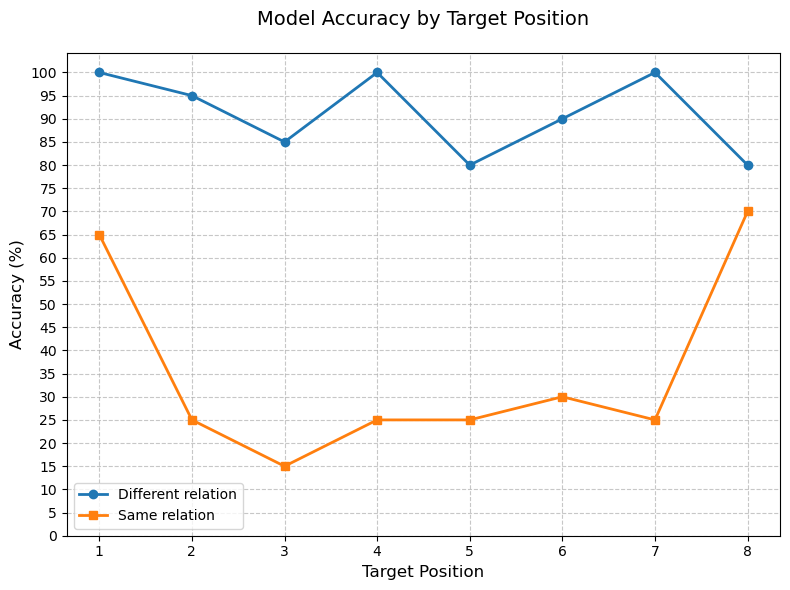

In [8]:
import matplotlib.pyplot as plt

def plot_custom_accuracy_comparison():
    x = list(range(1, 9))
    
    # First line: Different relation
    y1 = [1.00, 0.95, 0.85, 1.00, 0.80, 0.90, 1.00, 0.80]

    # Second line: different relation
    y2 = [0.65, 0.25, 0.15, 0.25, 0.25, 0.30, 0.25, 0.70]

    plt.figure(figsize=(8, 6))
    plt.plot(x, [val * 100 for val in y1], marker='o', label='Different relation', linewidth=2)
    plt.plot(x, [val * 100 for val in y2], marker='s', label='Same relation', linewidth=2)

    plt.title('Model Accuracy by Target Position', fontsize=14, pad=20)
    plt.xlabel('Target Position', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.yticks(range(0, 101, 5))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title_fontsize=12, fontsize=10)
    plt.tight_layout()
    return plt.gcf()

fig = plot_custom_accuracy_comparison()
fig.show()

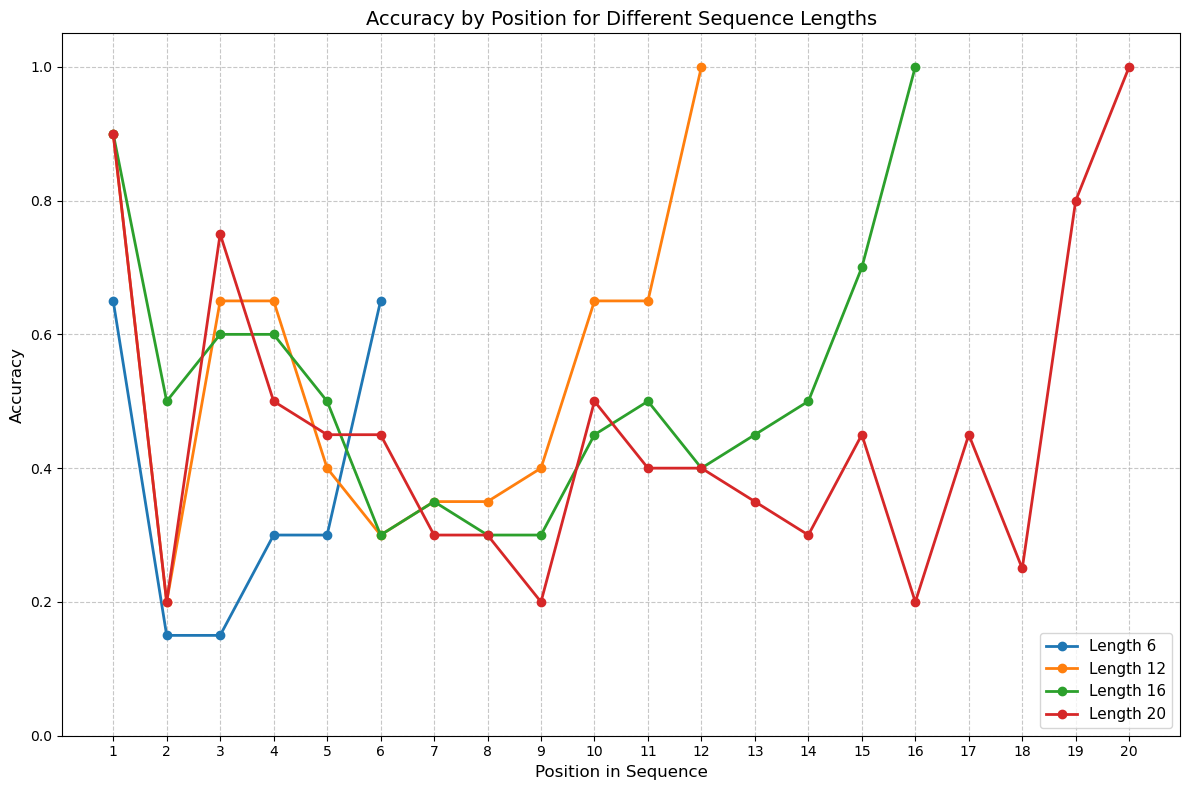

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_accuracy_results(results_files=None, base_dir="dataset", sequence_lengths=None, figsize=(12, 8), save_path=None):
    """
    Plot accuracy results from previously generated CSV files.
    
    Parameters:
    -----------
    results_files : list of str, optional
        List of paths to results CSV files. If None, will use default naming pattern.
    base_dir : str, optional
        Base directory where result files are located, used only if results_files is None.
    sequence_lengths : list of int, optional
        Sequence lengths to plot. If None, will use [6, 12, 16, 20].
    figsize : tuple, optional
        Figure size (width, height) in inches.
    save_path : str, optional
        Path to save the plot. If None, will not save the plot.
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object containing the plot.
    """
    # Default sequence lengths if not provided
    if sequence_lengths is None:
        sequence_lengths = [6, 12, 16, 20]
    
    # Use default file naming pattern if results_files not provided
    if results_files is None:
        results_files = [f"{base_dir}/results_{length}.csv" for length in sequence_lengths]
    
    # Check if files exist
    for file_path in results_files:
        if not os.path.exists(file_path):
            print(f"Warning: {file_path} does not exist.")
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    all_accuracies_by_position = []
    
    # Colors for different sequence lengths
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    # Process each results file
    for i, (file_path, length) in enumerate(zip(results_files, sequence_lengths)):
        try:
            # Load results
            df = pd.read_csv(file_path)
            
            # Calculate accuracy by position
            accuracy_by_position = df.groupby('target_position')['is_correct'].mean()
            all_accuracies_by_position.append(accuracy_by_position)
            
            # Get positions and accuracies
            positions = list(accuracy_by_position.index)
            accuracies = list(accuracy_by_position.values)
            
            # Plot accuracy by position
            ax.plot(positions, accuracies, marker='o', label=f'Length {length}', 
                    color=colors[i % len(colors)], linewidth=2)
            
        except Exception as e:
            print(f"Error processing {file_path}: {str(e)}")
    
    # Style the plot
    ax.set_xlabel('Position in Sequence', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Accuracy by Position for Different Sequence Lengths', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylim(0, 1.05)  # Set y-axis from 0 to slightly above 1
    
    # Add legend
    ax.legend(fontsize=11)
    
    # Set x-ticks to be integers
    max_position = max([max(acc.index) for acc in all_accuracies_by_position if not acc.empty])
    ax.set_xticks(np.arange(1, max_position + 1))
    
    plt.tight_layout()
    
    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    return fig

# Example usage in your notebook:
# Just call the function with your specific parameters
fig = plot_accuracy_results()
plt.show()